# Replication code

## 1. Imports and relative paths

In [1]:
# set path
import importlib
import sys, os
import math
sys.path.append(os.path.abspath(".."))
from typing import Optional
import warnings

import pandas as pd
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRFRegressor

from src import dynamic
from src import auxilaries
from src import hurdleregression
importlib.reload(dynamic)
importlib.reload(auxilaries)
importlib.reload(hurdleregression)
from src.dynamic import DynamicModelManager, ModelConfig
from src.auxilaries import (
    load_queryset, 
    month_id_to_ym, date_to_month_id
)
from src.plotting import (
    plot_error_over_time, plot_aggregated_error_over_time, 
    plot_skill_score_over_time, plot_combined_skill_score_over_time,
    plot_combined_error_over_time, get_disaggregated_metrics
)
from src.hurdleregression import HurdleRegression

Set paths to data and figure folders:

In [25]:
data_path = "data/"
views_data_path = "data/views_data/"
auxiliary_data_path = "data/auxiliary/"
figure_path = "figs/"

## 2. Descriptive statistics

Read in one of the querysets and retrieve battle-related deaths by year:

In [29]:
# read in full dataset
data = pd.read_parquet(f"{views_data_path}fatalities002_conflict_history.parquet").reset_index()

# select relevant columns
data = data[["month_id", "country_id", "ln_ged_sb"]]

# create non-logged version of fatalities
data["ged_sb"] = np.expm1(data["ln_ged_sb"])

# add year column
data["year"] = data["month_id"].apply(lambda x: int(month_id_to_ym(x).split(" ")[1]))

Read in country_id to country_name mapping and add country names to the data frame:

In [31]:
country_id_name = pd.read_csv(f"{auxiliary_data_path}country_id_to_name.csv")

country_name_dict = (
    country_id_name.groupby('name')['country_id']
    .apply(list)
    .to_dict()
)
country_id_dict = dict(zip(country_id_name["country_id"], country_id_name["name"]))

data["country_name"] = data["country_id"].map(country_id_dict)

Aggregate battle-related deaths by year and plot:

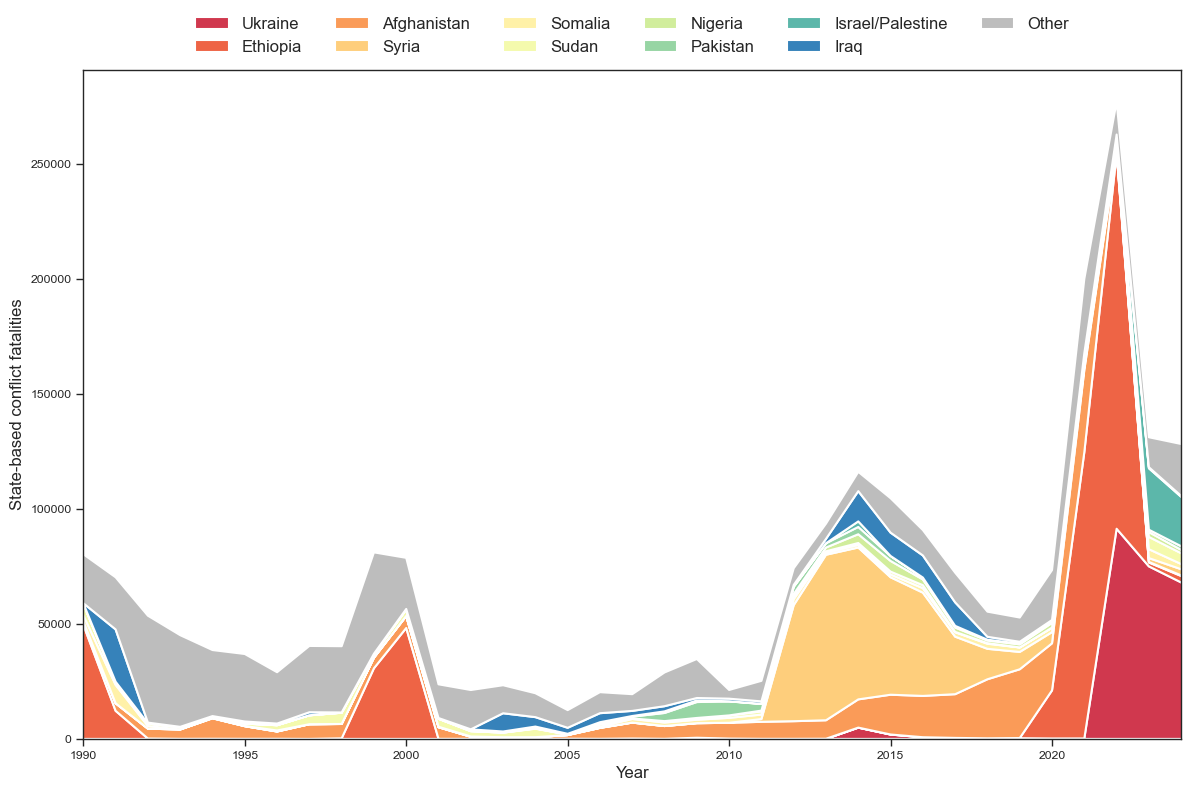

In [37]:
# aggregate data to yearly fatalities by country
df_stack = (
    data.groupby(["year", "country_name"])["ged_sb"]
      .sum()
      .unstack(fill_value=0)
)

# keep top 10 countries
top = df_stack.sum().nlargest(10).index

# add "Other" category
df_stack["Other"] = df_stack.drop(columns=top).sum(axis=1)
df_plot = df_stack[top.tolist() + ["Other"]]

# set color scheme
colors_main = sns.color_palette("Spectral", n_colors=len(df_plot.columns) - 1)
colors = list(colors_main) + ["#BDBDBD"]   # grey for Other

# set up figure
fig, ax = plt.subplots(figsize=(12,8))

# add label for Israel/palestine
labels = [
    "Israel/Palestine" if c == "Israel" else c
    for c in df_plot.columns
]

# create stackplot
stack = ax.stackplot(
    df_plot.index,
    df_plot.T.values,
    labels=labels,
    colors=colors,
    edgecolor="white",
    linewidth=1.5,
)

# plot metadata
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("State-based conflict fatalities", fontsize=12)
ax.set_xlim(1990, 2024)
ax.legend(
    stack,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    ncol=6,          
    frameon=False,
    fontsize=12
)

plt.tight_layout()
plt.savefig(f"{figure_path}figure_3.png", dpi=300)
plt.show()

## 3. Main results

### 3.1 Define constituent models from VIEWS:

In [113]:
random_state = 42

basic_model_replication = ModelConfig(
    name = 'Basic Model',
    model = RandomForestRegressor(
        random_state = random_state
    ),
    queryset = "fatalities002_joint_narrow",
    target="ln_ged_sb",
    features = [
       'ln_ged_sb_dep', 'ln_ged_sb', 'reign_tenure_months',
       'wdi_sp_pop_totl', 'wdi_ag_lnd_frst_k2', 'wdi_nv_agr_totl_kn',
       'wdi_sh_sta_maln_zs', 'wdi_sl_tlf_totl_fe_zs', 'wdi_sm_pop_refg_or',
       'wdi_sp_dyn_imrt_in', 'wdi_sp_pop_14_fe_zs', 'wdi_sp_pop_grow',
       'vdem_v2xcl_dmove', 'vdem_v2xcl_rol', 'vdem_v2xeg_eqdr',
       'vdem_v2xpe_exlpol', 'vdem_v2xpe_exlsocgr', 'ln_ged_sb_tlag_1',
       'ln_ged_sb_tlag_2', 'splag_wdi_ag_lnd_frst_k2',
       'splag_wdi_sl_tlf_totl_fe_zs', 'splag_wdi_sm_pop_netm',
       'splag_vdem_v2xpe_exlsocgr', 'splag_vdem_v2xcl_rol', 'decay_ged_sb_5',
       'decay_ged_os_5',  'splag_1_decay_ged_sb_5'
    ]
)

conflict_history = ModelConfig(
    name = 'Conflict History Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_conflict_history",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb', 'ln_ged_ns', 'ln_ged_os', 'ln_acled_sb', 'ln_acled_sb_count', 
        'ln_acled_os', 'wdi_sp_pop_totl', 'ln_ged_sb_tlag_1', 'ln_ged_sb_tlag_2', 
        'ln_ged_sb_tlag_3', 'ln_ged_sb_tlag_4', 'ln_ged_sb_tlag_5','ln_ged_sb_tlag_6', 
        'ln_ged_sb_tsum_24', 'ln_ged_os_tlag_1','decay_ged_sb_5', 'decay_ged_os_5', 
        'splag_1_decay_ged_sb_5', 'splag_1_decay_ged_os_5','splag_1_decay_ged_ns_5'
    ]
)

narrow_model = ModelConfig(
    name = 'Narrow Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_joint_narrow",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb', 'reign_tenure_months', 'wdi_sp_pop_totl',
        'wdi_ag_lnd_frst_k2', 'wdi_nv_agr_totl_kn', 'wdi_sh_sta_maln_zs',
        'wdi_sl_tlf_totl_fe_zs', 'wdi_sm_pop_refg_or', 'wdi_sp_dyn_imrt_in',
        'wdi_sp_pop_14_fe_zs', 'wdi_sp_pop_grow', 'vdem_v2xcl_dmove',
        'vdem_v2xcl_rol', 'vdem_v2xeg_eqdr', 'vdem_v2xpe_exlpol',
        'vdem_v2xpe_exlsocgr', 'ln_ged_sb_tlag_1', 'ln_ged_sb_tlag_2',
        'splag_wdi_ag_lnd_frst_k2', 'splag_wdi_sl_tlf_totl_fe_zs',
        'splag_wdi_sm_pop_netm', 'splag_vdem_v2xpe_exlsocgr',
        'splag_vdem_v2xcl_rol', 'decay_ged_sb_5',
        'splag_1_decay_ged_sb_5','decay_ged_os_5'
    ]
)

broad_model = ModelConfig(
    name = 'Broad Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_joint_broad",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb','ln_ged_ns','ln_ged_os','ln_acled_sb',
        'ln_acled_sb_count','ln_acled_os','wdi_sm_pop_netm','wdi_sm_pop_refg_or',
        'wdi_dt_oda_odat_pc_zs','wdi_ms_mil_xpnd_gd_zs','wdi_sl_tlf_totl_fe_zs',
        'wdi_nv_agr_totl_kn','wdi_sp_pop_grow','wdi_se_enr_prim_fm_zs','wdi_sp_urb_totl_in_zs',
        'wdi_sh_sta_maln_zs','wdi_sp_dyn_imrt_fe_in','wdi_ny_gdp_mktp_kd','wdi_sh_sta_stnt_zs',
        'vdem_v2x_horacc','vdem_v2xnp_client','vdem_v2x_veracc','vdem_v2x_divparctrl','vdem_v2xpe_exlpol',
        'vdem_v2x_diagacc','vdem_v2xpe_exlgeo','vdem_v2xpe_exlgender','vdem_v2xpe_exlsocgr',
        'vdem_v2x_ex_party','vdem_v2x_genpp','vdem_v2xeg_eqdr','vdem_v2xcl_prpty','vdem_v2xeg_eqprotec',
        'vdem_v2x_ex_military','vdem_v2xcl_dmove','vdem_v2x_clphy','vdem_v2x_hosabort','vdem_v2xnp_regcorr',
        'wdi_sp_pop_totl','ln_ged_sb_tlag_1','ln_ged_sb_tlag_2','ln_ged_sb_tlag_3','ln_ged_sb_tlag_4','ln_ged_sb_tlag_5',
        'ln_ged_sb_tlag_6','ln_ged_os_tlag_1','topic_tokens_t1','topic_tokens_t2','topic_ste_theta4_stock_t1',
        'topic_ste_theta4_stock_t2','topic_ste_theta4_stock_t13','topic_ste_theta2_stock_t1','topic_ste_theta2_stock_t2',
        'topic_ste_theta2_stock_t13','splag_wdi_sl_tlf_totl_fe_zs','splag_wdi_sm_pop_refg_or','splag_wdi_sm_pop_netm',
        'splag_wdi_ag_lnd_frst_k2','splag_vdem_v2x_libdem','splag_vdem_v2xcl_dmove','splag_vdem_v2x_accountability',
        'splag_vdem_v2xpe_exlsocgr','splag_vdem_v2xcl_rol','decay_ged_sb_5','decay_ged_os_5','splag_1_decay_ged_sb_5',
        'splag_1_decay_ged_os_5','splag_1_decay_ged_ns_5','topic_ste_theta4_stock_t1_splag','topic_ste_theta2_stock_t1_splag'
    ]
)

vdem_model = ModelConfig(
    name = 'VDEM Model',
    model = HurdleRegression(clf_name='XGBClassifier', reg_name='XGBRegressor'),
    queryset = "fatalities002_vdem_short",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb', 'vdem_v2x_delibdem', 'vdem_v2x_egaldem',
        'vdem_v2x_libdem', 'vdem_v2x_libdem_48', 'vdem_v2x_partip',
        'vdem_v2x_partipdem', 'vdem_v2x_accountability', 'vdem_v2x_civlib',
        'vdem_v2x_clphy', 'vdem_v2x_cspart', 'vdem_v2x_divparctrl',
        'vdem_v2x_edcomp_thick', 'vdem_v2x_egal', 'vdem_v2x_execorr',
        'vdem_v2x_frassoc_thick', 'vdem_v2x_gencs', 'vdem_v2x_gender',
        'vdem_v2x_genpp', 'vdem_v2x_horacc', 'vdem_v2x_neopat',
        'vdem_v2x_pubcorr', 'vdem_v2x_rule', 'vdem_v2x_veracc',
        'vdem_v2x_ex_military', 'vdem_v2x_ex_party', 'vdem_v2x_freexp',
        'vdem_v2xcl_acjst', 'vdem_v2xcl_dmove', 'vdem_v2xcl_prpty',
        'vdem_v2xcl_rol', 'vdem_v2xcl_slave', 'vdem_v2xdd_dd',
        'vdem_v2xdl_delib', 'vdem_v2xeg_eqdr', 'vdem_v2xeg_eqprotec',
        'vdem_v2xel_frefair', 'vdem_v2xel_regelec', 'vdem_v2xme_altinf',
        'vdem_v2xnp_client', 'vdem_v2xnp_regcorr', 'vdem_v2xpe_exlecon',
        'vdem_v2xpe_exlpol', 'vdem_v2xpe_exlgeo', 'vdem_v2xpe_exlgender',
        'vdem_v2xpe_exlsocgr', 'vdem_v2xps_party', 'vdem_v2xcs_ccsi',
        'vdem_v2xnp_pres', 'vdem_v2xeg_eqaccess', 'vdem_v2x_diagacc',
        'vdem_v2clrgunev', 'wdi_sm_pop_netm', 'wdi_sp_dyn_imrt_in',
        'wdi_sp_pop_totl', 'splag_vdem_v2x_libdem', 'splag_vdem_v2xcl_dmove',
        'splag_vdem_v2x_accountability', 'splag_vdem_v2xpe_exlsocgr',
        'splag_vdem_v2xcl_rol', 'decay_ged_sb_5', 'decay_ged_os_5',
        'splag_1_decay_ged_sb_5'
    ]
)

wdi_model = ModelConfig(
    name = 'WDI Model',
    model = XGBRFRegressor(
        n_estimators=250, random_state=random_state
    ),
    queryset = "fatalities002_wdi_short",
    target = "ln_ged_sb_dep",
    features = [
        'ln_ged_sb',
       'wdi_ag_lnd_frst_k2', 'wdi_dt_oda_odat_pc_zs', 'wdi_ms_mil_xpnd_gd_zs',
       'wdi_ms_mil_xpnd_zs', 'wdi_nv_agr_totl_kd', 'wdi_nv_agr_totl_kn',
       'wdi_ny_gdp_pcap_kd', 'wdi_sp_dyn_le00_in', 'wdi_se_enr_prim_fm_zs',
       'wdi_se_enr_prsc_fm_zs', 'wdi_se_prm_nenr', 'wdi_sh_sta_maln_zs',
       'wdi_sh_sta_stnt_zs', 'wdi_sl_tlf_totl_fe_zs', 'wdi_sm_pop_refg_or',
       'wdi_sm_pop_netm', 'wdi_sm_pop_totl_zs', 'wdi_sp_dyn_imrt_in',
       'wdi_sh_dyn_mort_fe', 'wdi_sp_pop_14_fe_zs', 'wdi_sp_pop_1564_fe_zs',
       'wdi_sp_pop_65up_fe_zs', 'wdi_sp_pop_grow', 'wdi_sp_urb_totl_in_zs',
       'wdi_sp_pop_totl', 'splag_wdi_sl_tlf_totl_fe_zs',
       'splag_wdi_sm_pop_refg_or', 'splag_wdi_sm_pop_netm',
       'splag_wdi_ag_lnd_frst_k2', 'decay_ged_sb_5', 'decay_ged_os_5',
       'splag_1_decay_ged_sb_5'
    ]
)

In [124]:
model_list = [narrow_model, broad_model, wdi_model, vdem_model, conflict_history]

### 3.2 Train all models and make predictions for test sets

Set up parameters

In [6]:
step = 12 # predicting 12 months into the future
train_window_size = 120 # using 10 years of monthly data to train each model
test_window_size = 12 # test periods of 1 year
slide_window_size = 12 # sliding the window by 1 year for each iteration
full_split = (
    date_to_month_id(1990, 0), # January 1990
    date_to_month_id(2025, 0)  # December 2024
)

And train and predict with all models

In [ ]:
managers: dict[str, DynamicModelManager] = {}

for model in model_list:
    print(f"Running model: {model.name}")

    model_data = load_queryset(model.queryset, views_data_path).reset_index()
    
    manager = DynamicModelManager(
        steps = [3,6,12,24],
        data = model_data,
        features = model.features,
        target = model.target,
        model_name= model.name,
        base_model = model.model,
        train_window_size = train_window_size,
        test_window_size = test_window_size,
        slide_window_size = slide_window_size,
        full_split = full_split,
        target_log_transformed=True
    )

    manager.fit()
    manager.predict()

    managers[model.name] = manager

Running model: Narrow Model
Loading fatalities002_joint_narrow from local storage...


Fitting models: 100%|██████████| 96/96 [00:53<00:00,  1.81it/s]


Finished fitting all models in 53.19 seconds


Predicting: 100%|██████████| 2208/2208 [00:13<00:00, 168.08it/s]


Running model: Broad Model
Loading fatalities002_joint_broad from local storage...


...

Predicting: 100%|██████████| 2208/2208 [00:19<00:00, 114.65it/s]


Running model: Conflict History Model
Loading fatalities002_conflict_history from local storage...


Fitting models: 100%|██████████| 96/96 [00:43<00:00,  2.22it/s]


Finished fitting all models in 43.24 seconds


Predicting: 100%|██████████| 2208/2208 [00:11<00:00, 186.16it/s]


### 3.3 Descriptive statistics

Set colormap for the plot

In [41]:
colormap = {
    "Broad Model": "peru",
    "Narrow Model": "grey",
    "WDI Model": "steelblue",
    "VDEM Model": "rebeccapurple",
    "Conflict History Model": "maroon",
}

#### Figure 4: Baseline MSLE by testing period

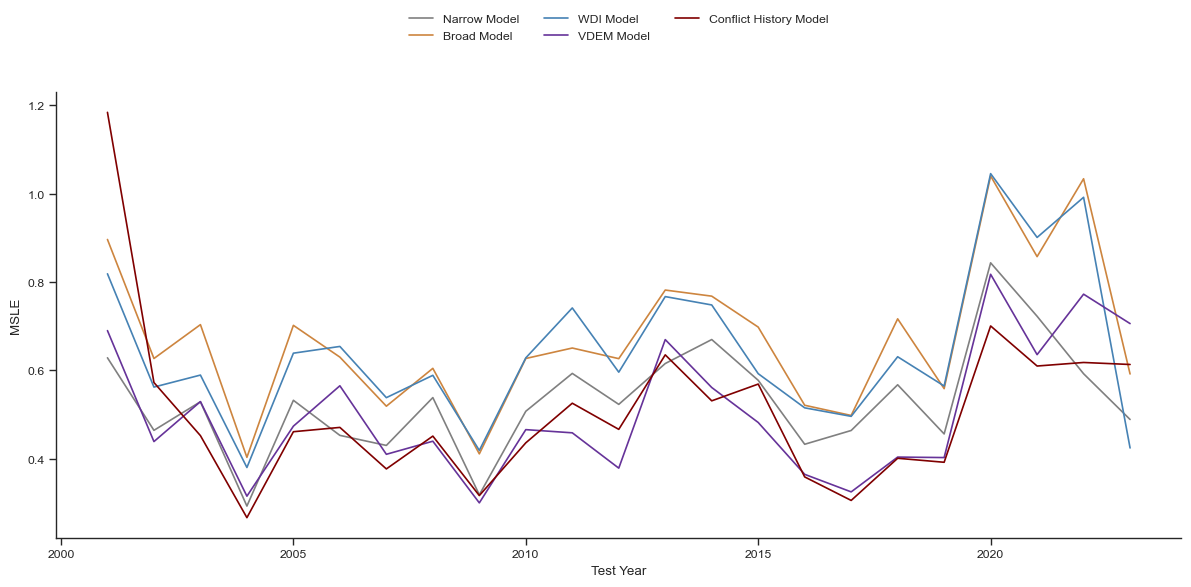

In [46]:
plt.figure(figsize=(12, 6))

for model in managers.keys():
    manager = managers[model]

    metrics = get_disaggregated_metrics(manager)
    metrics = metrics[metrics["step"] == step]

    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()
    grouped_positive = grouped[grouped["distance"] > 0]

    grouped_positive = grouped_positive[grouped_positive["distance"] == 6.5]

    grouped_positive["year"] = grouped_positive["test_start"].apply(lambda x: int(month_id_to_ym(x).split(" ")[1]))

    sns.lineplot(data=grouped_positive, x="year", 
                y="squared_log_error", legend=False, label = model, 
                color = colormap[model] if colormap is not None and model in colormap else None)

#plt.title(f"MSLE over Time of models at Step {step} for Distance Bin {6.5}")
plt.xlabel("Test Year")
plt.ylabel("MSLE")
plt.legend(
        loc="upper center",
        ncol=math.ceil(len(managers) / 2),
        bbox_to_anchor=(0.5, 1.20),
        frameon=False
    )
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_4.png", dpi=300)
plt.show()

### 3.4 Main results

#### Figure 5: MSLE by distance for all models

And then plot MSLE by distance for all models

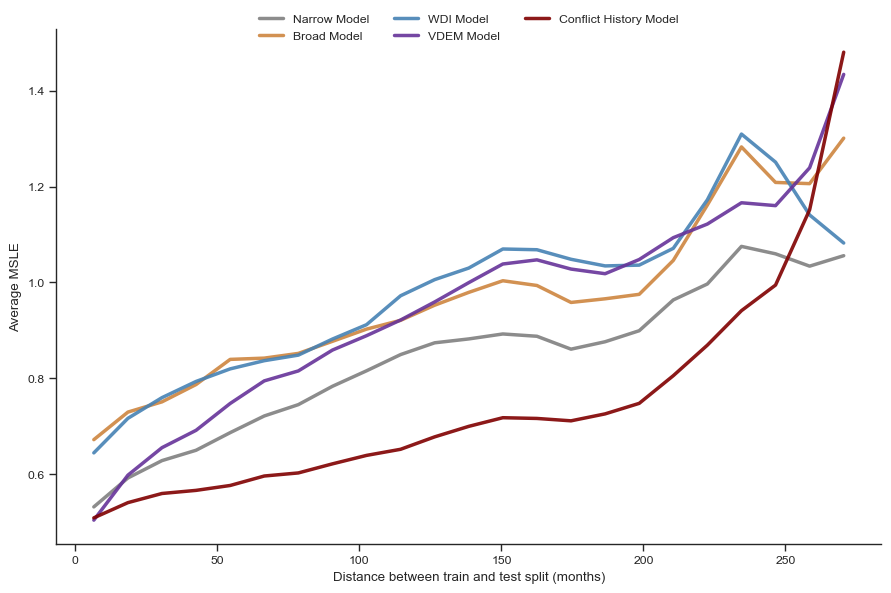

In [47]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

sns.set_palette("muted")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    # only plot for the future
    grouped = grouped[grouped["distance"] > 0]

    # plot mean mse and std of mse against distance
    sns.lineplot(
        data=grouped,
        x="distance",
        y="squared_log_error",   
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name]
        )
    
plt.xlabel("Distance between train and test split (months)")
plt.ylabel(f"Average MSLE")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
)
sns.despine()
plt.tight_layout()

plt.savefig(f"{figure_path}figure_5.png", dpi=300)
plt.show()

#### Figure 6: Skill score by distance between train and test period

In [50]:
group_by = "test_start"
step = 12
metric = "squared_log_error"
label = "MSLE"
future = True

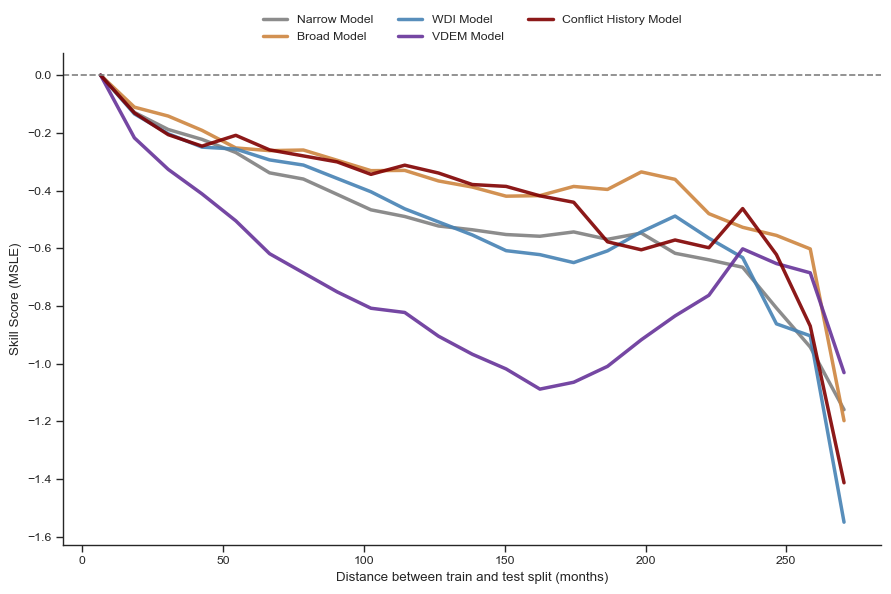

In [73]:
from src.plotting import calculate_skill_score

# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_6.png", dpi = 300)
plt.show()

### 3.5 Extensions and Robustness

#### Figure 7: 

Excluding Ethiopia, Israel and Ukraine:

In [53]:
print(country_name_dict["Israel"])
print(country_name_dict["Ethiopia"])
print(country_name_dict["Ukraine"])

[218]
[57, 191]
[117]


And create a list of countries to filter out:

In [ ]:
filter_list = [117, 57, 191, 218]

# only plot three models to avoid clutter:
managers_filt = {k: v for k, v in managers.items() if k in ["Broad Model", "Narrow Model", "Conflict History Model"]}

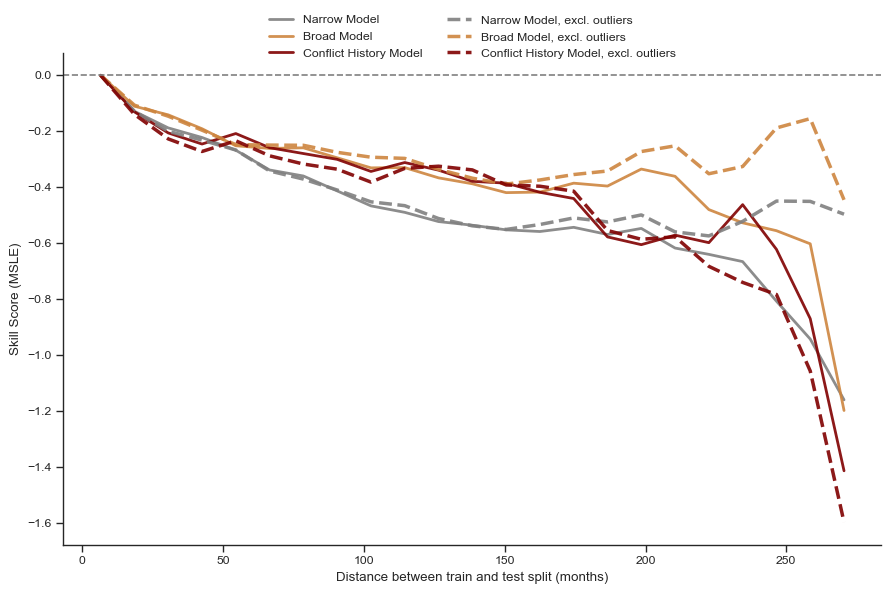

In [69]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers_filt.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric, future = future) #type: ignore

    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}",    # separate lines by test_start
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )

# get metrics for each model and plot error over time
for model_name in managers_filt.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # filter out countries if specified (e.g., for robustness checks)
    metrics = metrics[~metrics["country_id"].isin(filter_list)]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric, future = future) #type: ignore

    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}, excl. outliers",
        linewidth=2.5,
        linestyle="--",
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_7.png", dpi=300)
plt.show()

#### Figure 8: Skill score by backwards distance between train and test data

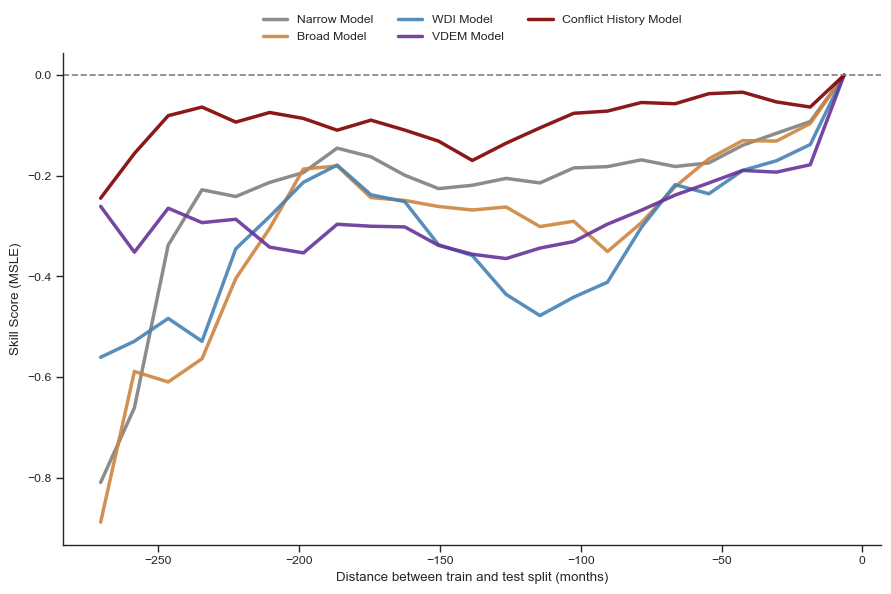

In [74]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == step]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric, future=False) #type: ignore

    # only keep past predictions 
    skill_score = skill_score[skill_score["distance"] < 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}figure_8.png", dpi=300)
plt.show()

## Appendix: Additional plots

### Appendix A: Skill score and MSLE plots for steps 3, 6, and 24

MSLE plots:

MSLE plot for step 3


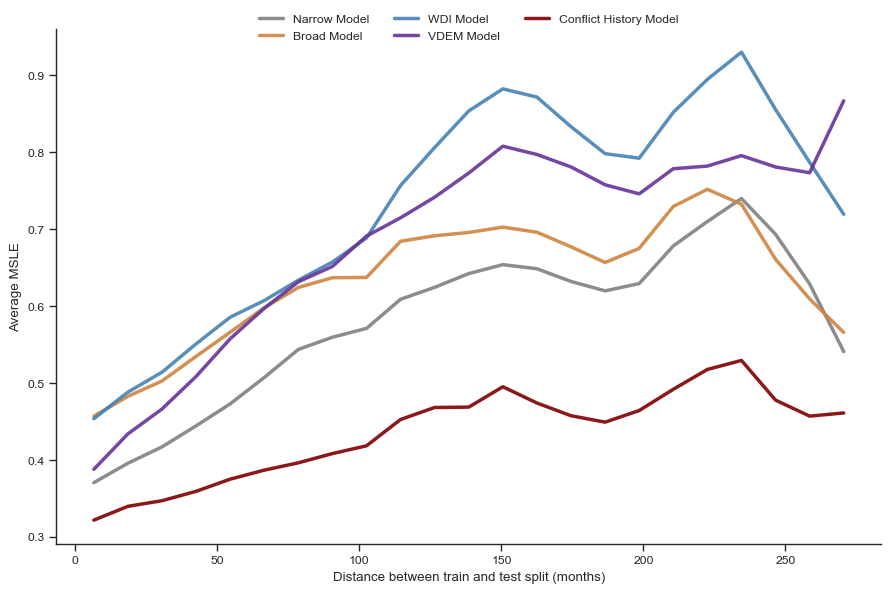

MSLE plot for step 6


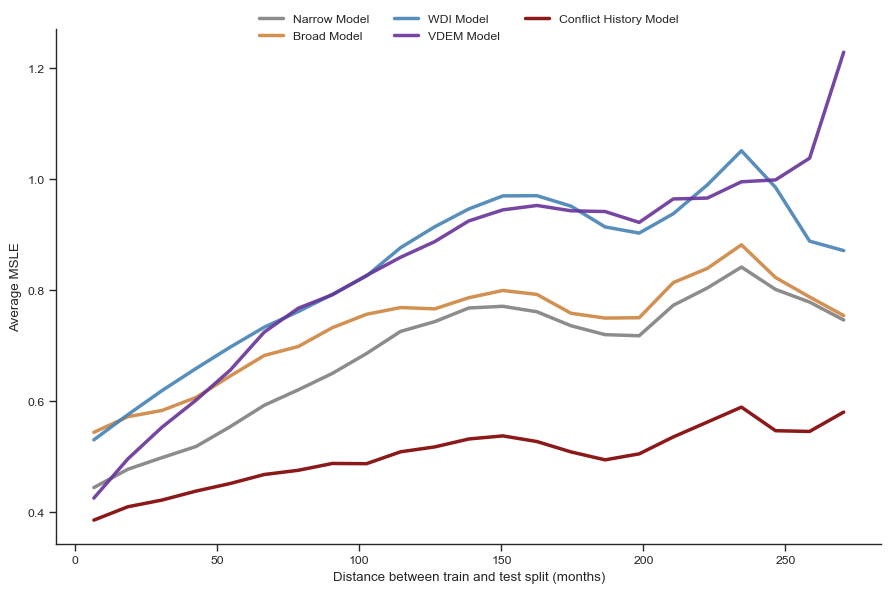

MSLE plot for step 24


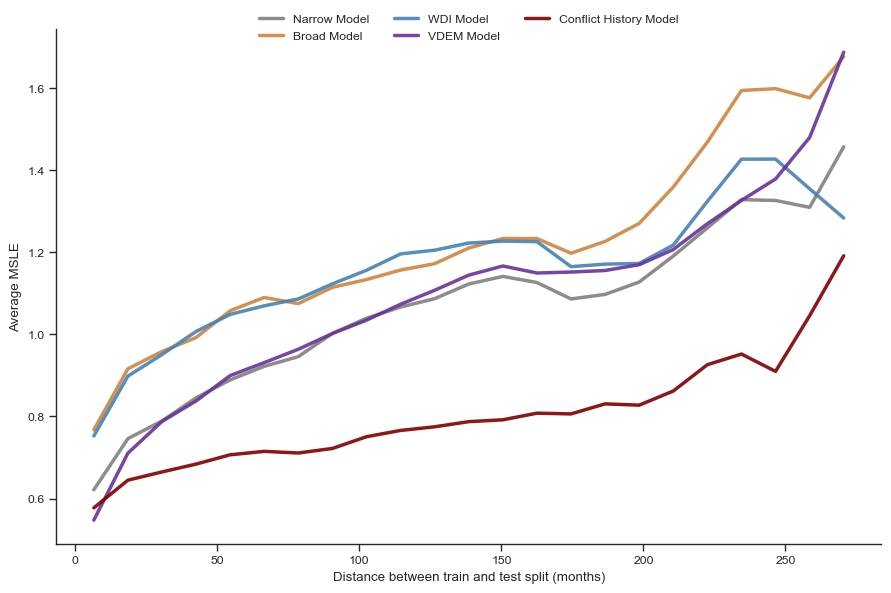

In [79]:
for step in [3, 6, 24]:

    print(f"MSLE plot for step {step}")

    plt.figure(figsize=(9, 6))
    sns.set_theme(style="ticks", context="paper")
    sns.set_palette("muted")

    # get metrics for each model and plot error over time
    for model_name in managers.keys():

        metrics = get_disaggregated_metrics(managers[model_name])

        # subset to specified step
        metrics = metrics[metrics["step"] == step]

        # calculate mean squared [log] error for each test_start, train_start combination
        grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

        # only plot for the future
        grouped = grouped[grouped["distance"] > 0]

        # plot mean mse and std of mse against distance
        sns.lineplot(
            data=grouped,
            x="distance",
            y="squared_log_error",   
            estimator="mean",
            errorbar=None,
            label= f"{model_name}",
            linewidth=2.5,
            alpha = 0.9,
            color = colormap[model_name]
            )
        
    plt.xlabel("Distance between train and test split (months)")
    plt.ylabel(f"Average MSLE")
    plt.legend(
        loc="upper center",
        ncol=math.ceil(len(managers) / 2),
        bbox_to_anchor=(0.5, 1.05),
        frameon=False,
    )
    sns.despine()
    plt.tight_layout()

    plt.savefig(f"{figure_path}appendix_a_msle_{step}.png", dpi=300)
    plt.show()

Skill score plots:

Skill Score plot for step 3


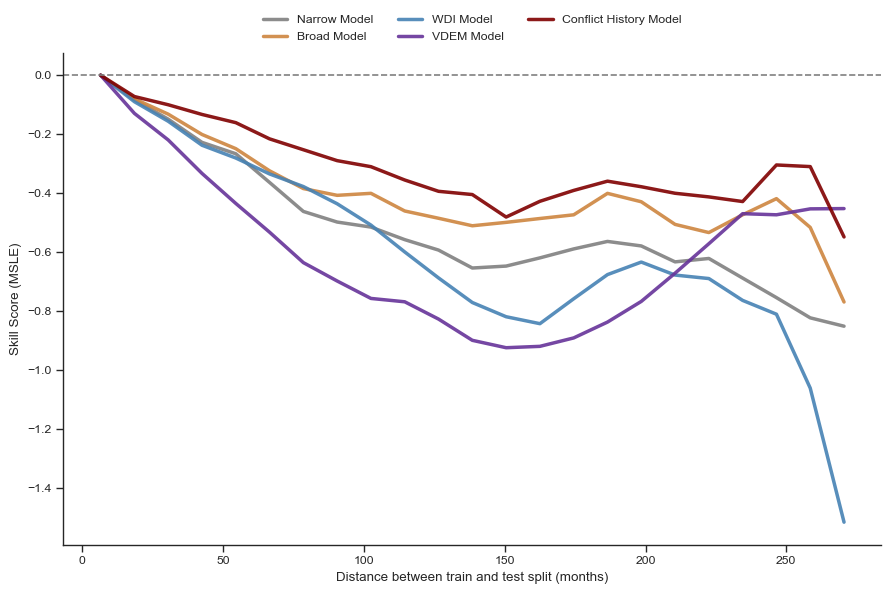

Skill Score plot for step 6


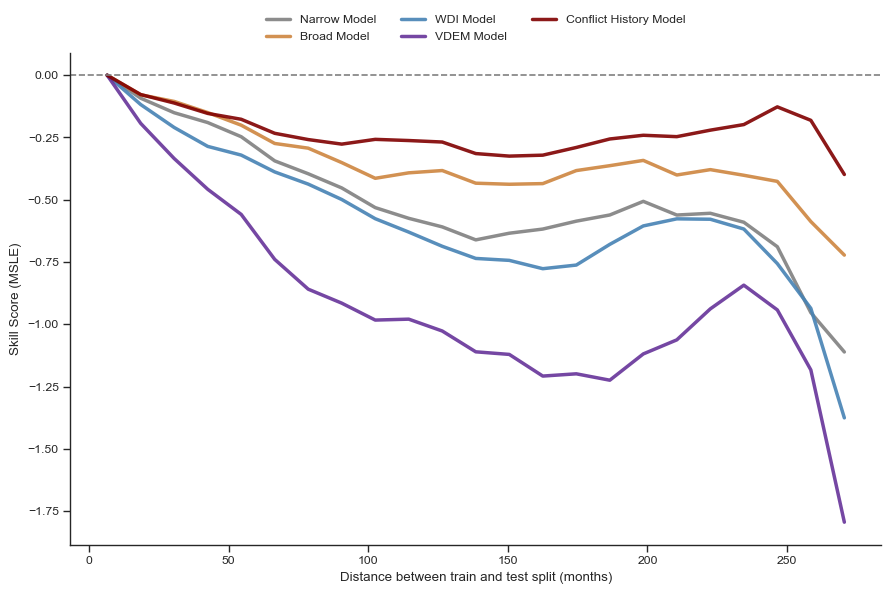

Skill Score plot for step 24


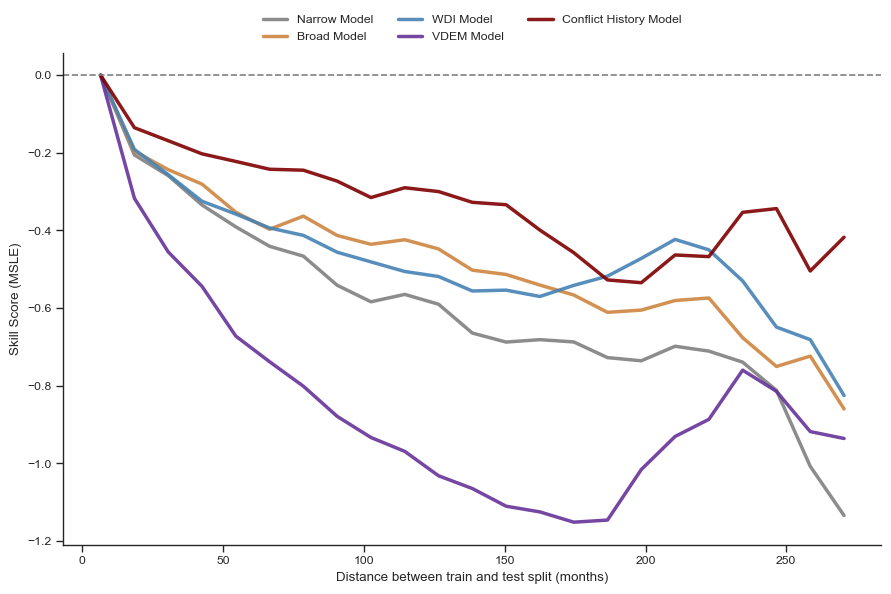

In [80]:
for step in [3, 6, 24]:

    print(f"Skill Score plot for step {step}")

    # set up plot
    plt.figure(figsize=(9, 6))
    sns.set_theme(style="ticks", context="paper")

    # get metrics for each model and plot error over time
    for model_name in managers.keys():

        metrics = get_disaggregated_metrics(managers[model_name])

        # subset to specified step
        metrics = metrics[metrics["step"] == step]

        # calculate mean squared [log] error for each test_start, train_start combination
        grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

        skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric) #type: ignore

        # only keep future predictions
        skill_score = skill_score[skill_score["distance"] > 0]

        sns.lineplot(
            data=skill_score,
            x="distance",
            y=f"skill_score_{metric}", 
            estimator="mean",
            errorbar=None,
            label= f"{model_name}",
            linewidth=2.5,
            alpha = 0.9,
            color = colormap[model_name] if colormap is not None and model_name in colormap else None
        )
        
    plt.xlabel("Distance between train and test split (months)")
    plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
    plt.ylabel(f"Skill Score ({label})")
    plt.legend(
        loc="upper center",
        ncol=math.ceil(len(managers) / 2),
        bbox_to_anchor=(0.5, 1.10),
        frameon=False
    )
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{figure_path}appendix_a_skill_score_{step}.png", dpi = 300)
    plt.show()

### Appendix B: MSLE by distance when predicting backwards

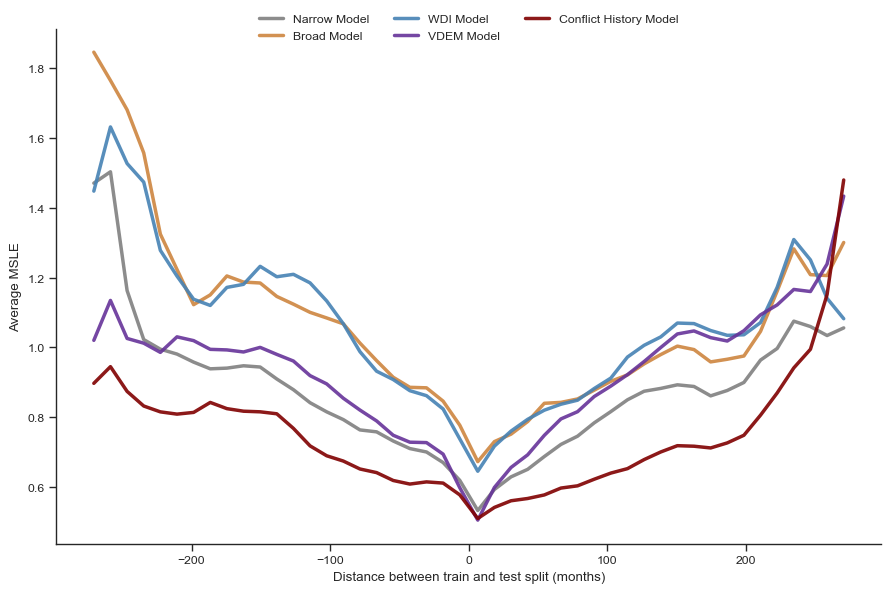

In [82]:
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

sns.set_palette("muted")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[["squared_log_error", "distance"]].mean().reset_index()

    # only plot for the future
    #grouped = grouped[grouped["distance"] > 0]

    # plot mean mse and std of mse against distance
    sns.lineplot(
        data=grouped,
        x="distance",
        y="squared_log_error",   
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name]
        )
    
plt.xlabel("Distance between train and test split (months)")
plt.ylabel(f"Average MSLE")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
)
sns.despine()
plt.tight_layout()

plt.savefig(f"{figure_path}appendix_b.png", dpi=300)
plt.show()

### Appendix C: Skill score plot, centering on training period

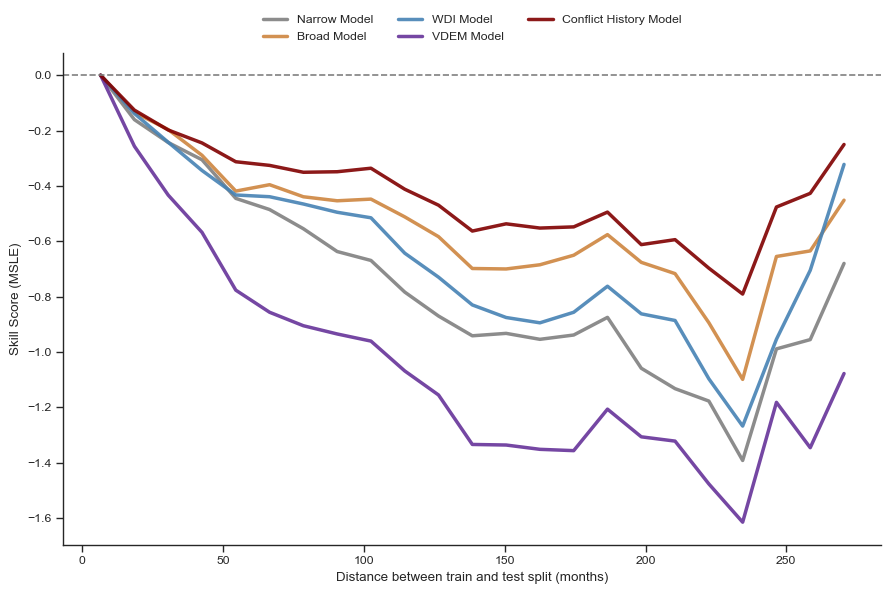

In [84]:
group_by = "train_start"

# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers.keys():

    metrics = get_disaggregated_metrics(managers[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}appendix_c.png", dpi = 300)
plt.show()

### Appendix D: Skill score plot with train period of 5 years, and 20 years

For this appendix, we first need to retrain the models with different training periods. We can then plot the skill score by distance for these different training periods.

#### Train window size of 5 years (60 months):

In [85]:
train_window_size = 60

In [86]:
managers_5_year: dict[str, DynamicModelManager] = {}

for model in model_list:
    print(f"Running model: {model.name}")

    model_data = load_queryset(model.queryset, views_data_path).reset_index()
    
    manager = DynamicModelManager(
        steps = [12],
        data = model_data,
        features = model.features,
        target = model.target,
        model_name= model.name,
        base_model = model.model,
        train_window_size = train_window_size,
        test_window_size = test_window_size,
        slide_window_size = slide_window_size,
        full_split = full_split,
        target_log_transformed=True
    )

    manager.fit()
    manager.predict()

    managers_5_year[model.name] = manager

Running model: Narrow Model
Loading fatalities002_joint_narrow from local storage...


Fitting models: 100%|██████████| 30/30 [00:14<00:00,  2.01it/s]


Finished fitting all models in 15.02 seconds


Predicting: 100%|██████████| 870/870 [00:05<00:00, 145.40it/s]


Running model: Broad Model
Loading fatalities002_joint_broad from local storage...


...

Predicting: 100%|██████████| 870/870 [00:07<00:00, 122.11it/s]


Running model: Conflict History Model
Loading fatalities002_conflict_history from local storage...


Fitting models: 100%|██████████| 30/30 [00:12<00:00,  2.40it/s]


Finished fitting all models in 12.49 seconds


Predicting: 100%|██████████| 870/870 [00:04<00:00, 179.31it/s]


And then plot the skill score:

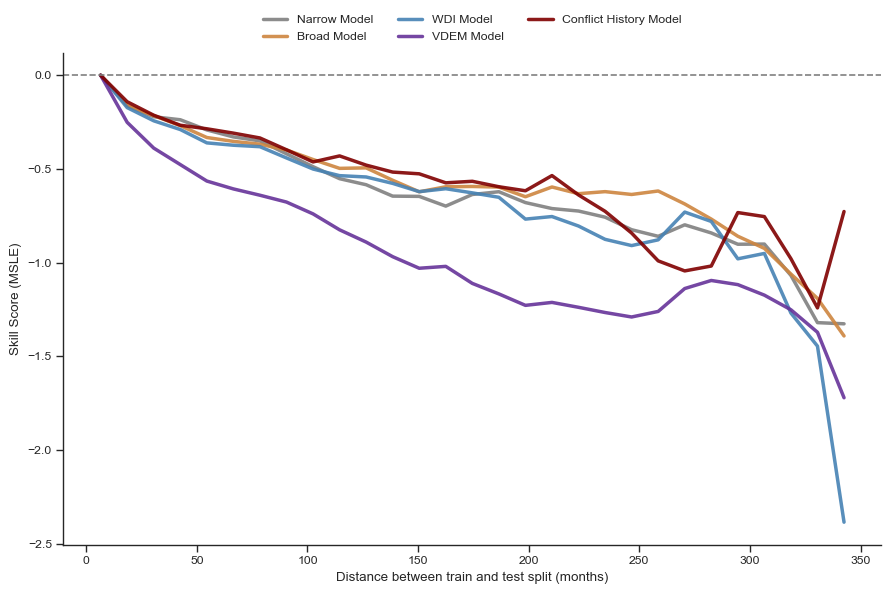

In [92]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

group_by = "test_start"

# get metrics for each model and plot error over time
for model_name in managers_5_year.keys():

    metrics = get_disaggregated_metrics(managers_5_year[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers_5_year) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}appendix_d_5_year.png", dpi = 300)
plt.show()

#### Train window size of 20 years (240 months):

In [87]:
train_window_size = 240

In [88]:
managers_20_year: dict[str, DynamicModelManager] = {}

for model in model_list:
    print(f"Running model: {model.name}")

    model_data = load_queryset(model.queryset, views_data_path).reset_index()
    
    manager = DynamicModelManager(
        steps = [12],
        data = model_data,
        features = model.features,
        target = model.target,
        model_name= model.name,
        base_model = model.model,
        train_window_size = train_window_size,
        test_window_size = test_window_size,
        slide_window_size = slide_window_size,
        full_split = full_split,
        target_log_transformed=True
    )

    manager.fit()
    manager.predict()

    managers_20_year[model.name] = manager

Running model: Narrow Model
Loading fatalities002_joint_narrow from local storage...


Fitting models: 100%|██████████| 15/15 [00:10<00:00,  1.48it/s]


Finished fitting all models in 10.12 seconds


Predicting: 100%|██████████| 210/210 [00:01<00:00, 154.75it/s]


Running model: Broad Model
Loading fatalities002_joint_broad from local storage...


...

Predicting: 100%|██████████| 210/210 [00:01<00:00, 123.42it/s]


Running model: Conflict History Model
Loading fatalities002_conflict_history from local storage...


Fitting models: 100%|██████████| 15/15 [00:07<00:00,  1.91it/s]


Finished fitting all models in 7.84 seconds


Predicting: 100%|██████████| 210/210 [00:01<00:00, 178.61it/s]


And then plot skill score:

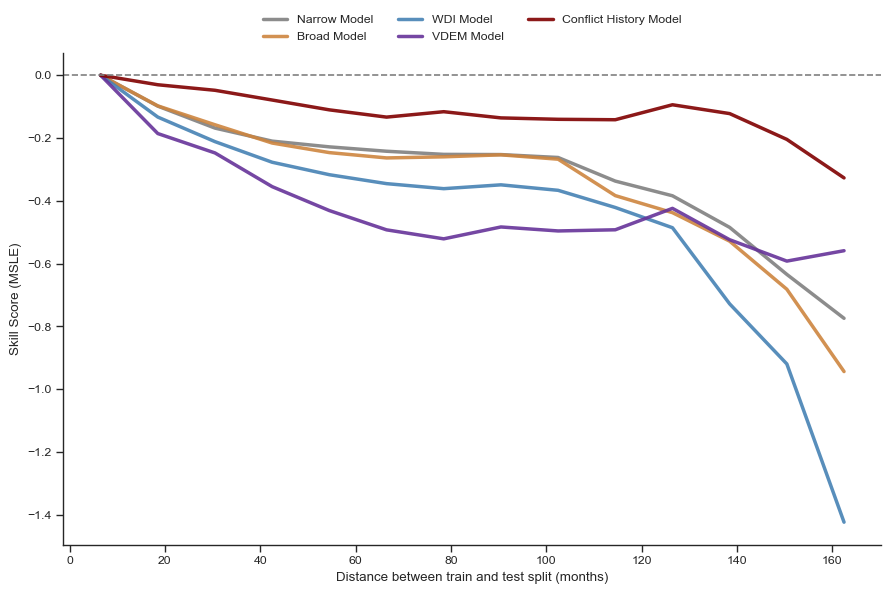

In [93]:
# set up plot
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="paper")

# get metrics for each model and plot error over time
for model_name in managers_20_year.keys():

    metrics = get_disaggregated_metrics(managers_20_year[model_name])

    # subset to specified step
    metrics = metrics[metrics["step"] == 12]

    # calculate mean squared [log] error for each test_start, train_start combination
    grouped = metrics.groupby(["test_start", "train_start"])[[metric, "distance"]].mean().reset_index()

    skill_score = calculate_skill_score(grouped, baseline=group_by, metric=metric) #type: ignore

    # only keep future predictions
    skill_score = skill_score[skill_score["distance"] > 0]

    sns.lineplot(
        data=skill_score,
        x="distance",
        y=f"skill_score_{metric}", 
        estimator="mean",
        errorbar=None,
        label= f"{model_name}",
        linewidth=2.5,
        alpha = 0.9,
        color = colormap[model_name] if colormap is not None and model_name in colormap else None
    )
    
plt.xlabel("Distance between train and test split (months)")
plt.axhline(0, linestyle="--", color="grey", linewidth=1.2)  # baseline reference
plt.ylabel(f"Skill Score ({label})")
plt.legend(
    loc="upper center",
    ncol=math.ceil(len(managers_20_year) / 2),
    bbox_to_anchor=(0.5, 1.10),
    frameon=False
)
sns.despine()
plt.tight_layout()
plt.savefig(f"{figure_path}appendix_d_20_year.png", dpi = 300)
plt.show()